# Parte 2: Red Neuronal con Numpy

**Trabajo Práctico — Matemática III: Redes Neuronales**  
**Dataset:** Water Potability  
**Integrantes:** Micaela Ortiz y Camila Maldonado

In [1]:
# Importamos numpy para calculos matriciales y operaciones de la red neuronal.
import numpy as np

# Importamos pandas para leer y preparar el CSV.
import pandas as pd

# train_test_split separa datos en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# seed fija la aleatoriedad del modulo random de Python.
from random import seed

# matplotlib sirve para graficar accuracy y costo.
import matplotlib.pyplot as plt

# Leemos el dataset.
df = pd.read_csv("../data/water_potability.csv")

# Imputamos valores faltantes con la mediana, igual que en Parte 1.
df["ph"] = df["ph"].fillna(df["ph"].median())
df["Sulfate"] = df["Sulfate"].fillna(df["Sulfate"].median())
df["Trihalomethanes"] = df["Trihalomethanes"].fillna(df["Trihalomethanes"].median())

# all_inputs contiene las 9 variables de entrada.
# Eliminamos Potability porque es la variable que queremos predecir.
all_inputs = df.drop(columns=["Potability"]).values.astype(float)

# all_outputs contiene la salida esperada: 0 no potable, 1 potable.
all_outputs = df["Potability"].values

# Normalizamos las entradas con Z-score.
# Esto evita que variables con numeros grandes dominen el entrenamiento.
all_inputs = (all_inputs - all_inputs.mean(axis=0)) / all_inputs.std(axis=0)

# Separamos los datos en entrenamiento y prueba.
# test_size=1/3 deja aproximadamente un tercio para test.
# random_state=42 fija la particion para que sea reproducible.
X_train, X_test, Y_train, Y_test = train_test_split(
    all_inputs,
    all_outputs,
    test_size=1/3,
    random_state=42
)

# n es la cantidad de muestras de entrenamiento.
n = X_train.shape[0]

# Mostramos las dimensiones de train y test.
X_train.shape, X_test.shape


((2184, 9), (1092, 9))

In [65]:
# Inicializacion de pesos y sesgos.

# Tasa de aprendizaje: define cuanto se ajustan los pesos en cada actualizacion.
L = 0.01

# Fijamos semillas para que los resultados sean reproducibles.
seed(10)
np.random.seed(10)

# Pesos entre capa de entrada y capa oculta.
# Forma: (8, 9) porque hay 8 neuronas ocultas y 9 entradas.
w_hidden = np.random.rand(8, 9)

# Pesos entre capa oculta y salida.
# Forma: (1, 8) porque hay 1 neurona de salida y 8 ocultas.
w_output = np.random.rand(1, 8)

# Sesgos de la capa oculta.
# Forma: (8, 1), uno por cada neurona oculta.
b_hidden = np.random.rand(8, 1)

# Sesgo de la neurona de salida.
b_output = np.random.rand(1, 1)

# Funcion ReLU para la capa oculta.
# Si x es negativo devuelve 0; si es positivo devuelve x.
relu = lambda x: np.maximum(x, 0)

# Funcion sigmoide/logistica para la salida.
# Devuelve valores entre 0 y 1, interpretables como probabilidad.
logistic = lambda x: 1 / (1 + np.exp(-x))

# Derivada de ReLU: 1 si x > 0, 0 si x <= 0.
d_relu = lambda x: x > 0

# Derivada de la sigmoide, usada en backpropagation.
d_logistic = lambda x: np.exp(-x) / (1 + np.exp(-x)) ** 2


In [66]:
# Propagacion hacia adelante.
# Esta funcion recibe una entrada X y calcula la prediccion de la red.
def forward_prop(X):
    # Z1 es la combinacion lineal de entradas, pesos y sesgos de la capa oculta.
    Z1 = w_hidden @ X + b_hidden

    # A1 es la activacion de la capa oculta luego de aplicar ReLU.
    A1 = relu(Z1)

    # Z2 es la combinacion lineal que llega a la neurona de salida.
    Z2 = w_output @ A1 + b_output

    # A2 es la salida final luego de aplicar sigmoide.
    # Es un valor entre 0 y 1.
    A2 = logistic(Z2)

    # Devolvemos valores intermedios porque se necesitan para backpropagation.
    return Z1, A1, Z2, A2


In [67]:
# Retropropagacion.
# Esta funcion calcula como deben ajustarse los pesos y sesgos para reducir el error.
def backward_prop(Z1, A1, Z2, A2, X, Y):
    # Derivada del error cuadratico respecto de la salida A2.
    # Si A2 esta lejos de Y, este valor sera mayor.
    dC_dA2 = 2 * A2 - 2 * Y

    # Derivada de la salida sigmoide respecto de Z2.
    dA2_dZ2 = d_logistic(Z2)

    # Derivadas de Z2 respecto de A1, W2 y B2.
    dZ2_dA1 = w_output
    dZ2_dW2 = A1
    dZ2_dB2 = 1

    # Derivada de la activacion ReLU de la capa oculta.
    dA1_dZ1 = d_relu(Z1)

    # Derivadas de Z1 respecto de W1 y B1.
    dZ1_dW1 = X
    dZ1_dB1 = 1

    # Gradiente de los pesos de salida.
    dC_dW2 = dC_dA2 * dA2_dZ2 @ dZ2_dW2.T

    # Gradiente del sesgo de salida.
    dC_dB2 = dC_dA2 * dA2_dZ2 * dZ2_dB2

    # Propagamos el error hacia la capa oculta.
    dC_dA1 = dZ2_dA1.T @ dC_dA2 * dA2_dZ2

    # Gradiente de los pesos de la capa oculta.
    dC_dW1 = dC_dA1 * dA1_dZ1 @ dZ1_dW1.T

    # Gradiente de los sesgos de la capa oculta.
    dC_dB1 = dC_dA1 * dA1_dZ1 * dZ1_dB1

    # Devolvemos todos los gradientes para actualizar parametros.
    return dC_dW1, dC_dB1, dC_dW2, dC_dB2


In [69]:
# Listas para guardar la evolucion del entrenamiento.
accuracy_train_l = []
accuracy_test_l = []
costo_train_l = []
costo_test_l = []

# Entrenamos durante 25000 iteraciones.
for i in range(25000):
    # Elegimos aleatoriamente una muestra del conjunto de entrenamiento.
    idx = np.random.choice(n, 1, replace=False)

    # Tomamos esa muestra y la transponemos para que tenga forma (9, 1).
    X_sample = X_train[idx].transpose()

    # Tomamos la salida real de esa muestra.
    Y_sample = Y_train[idx]

    # Forward pass: calculamos la prediccion actual.
    Z1, A1, Z2, A2 = forward_prop(X_sample)

    # Backpropagation: calculamos gradientes.
    dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

    # Actualizamos pesos y sesgos restando tasa_de_aprendizaje * gradiente.
    w_hidden -= L * dW1
    b_hidden -= L * dB1
    w_output -= L * dW2
    b_output -= L * dB2

    # Calculamos predicciones sobre todo el conjunto de entrenamiento.
    train_predictions = forward_prop(X_train.transpose())[3]

    # Convertimos probabilidades a clases usando umbral 0.5.
    train_comparisons = np.equal((train_predictions >= .5).flatten().astype(int), Y_train)

    # Accuracy = proporcion de predicciones correctas.
    accuracy_train = sum(train_comparisons.astype(int) / X_train.shape[0])
    accuracy_train_l.append(accuracy_train)

    # Repetimos el calculo para el conjunto de test.
    test_predictions = forward_prop(X_test.transpose())[3]
    test_comparisons = np.equal((test_predictions >= .5).flatten().astype(int), Y_test)
    accuracy_test = sum(test_comparisons.astype(int) / X_test.shape[0])
    accuracy_test_l.append(accuracy_test)

    # Calculamos error cuadratico medio en train y test.
    costo_train = np.mean((train_predictions.flatten() - Y_train) ** 2)
    costo_test = np.mean((test_predictions.flatten() - Y_test) ** 2)
    costo_train_l.append(costo_train)
    costo_test_l.append(costo_test)

    # Cada 1000 iteraciones imprimimos el estado para monitorear el entrenamiento.
    if i % 1000 == 0:
        print(f"Iteración {i} | Accuracy train: {accuracy_train:.4f} | Accuracy test: {accuracy_test:.4f}")


Iteración 0 | Accuracy train: 0.6607 | Accuracy test: 0.6694
Iteración 1000 | Accuracy train: 0.6593 | Accuracy test: 0.6786
Iteración 2000 | Accuracy train: 0.6731 | Accuracy test: 0.6749
Iteración 3000 | Accuracy train: 0.6571 | Accuracy test: 0.6648
Iteración 4000 | Accuracy train: 0.6690 | Accuracy test: 0.6749
Iteración 5000 | Accuracy train: 0.6680 | Accuracy test: 0.6813
Iteración 6000 | Accuracy train: 0.6717 | Accuracy test: 0.6722
Iteración 7000 | Accuracy train: 0.6708 | Accuracy test: 0.6703
Iteración 8000 | Accuracy train: 0.6644 | Accuracy test: 0.6767
Iteración 9000 | Accuracy train: 0.6703 | Accuracy test: 0.6731
Iteración 10000 | Accuracy train: 0.6712 | Accuracy test: 0.6758
Iteración 11000 | Accuracy train: 0.6763 | Accuracy test: 0.6731
Iteración 12000 | Accuracy train: 0.6722 | Accuracy test: 0.6795
Iteración 13000 | Accuracy train: 0.6712 | Accuracy test: 0.6694
Iteración 14000 | Accuracy train: 0.6740 | Accuracy test: 0.6786
Iteración 15000 | Accuracy train: 0.66

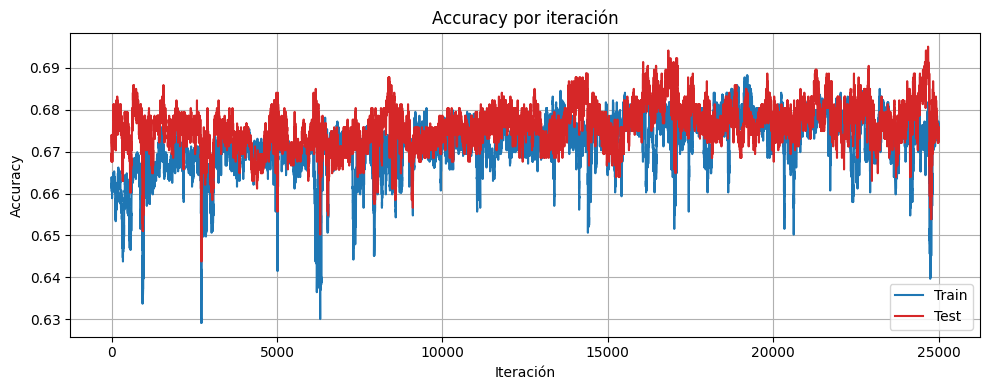

In [70]:
# Graficamos la accuracy a lo largo de las iteraciones.
plt.figure(figsize=(10, 4))

# Curva de entrenamiento.
plt.plot(accuracy_train_l, label='Train', color='tab:blue')

# Curva de prueba.
plt.plot(accuracy_test_l, label='Test', color='tab:red')

plt.title('Accuracy por iteración')
plt.xlabel('Iteración')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


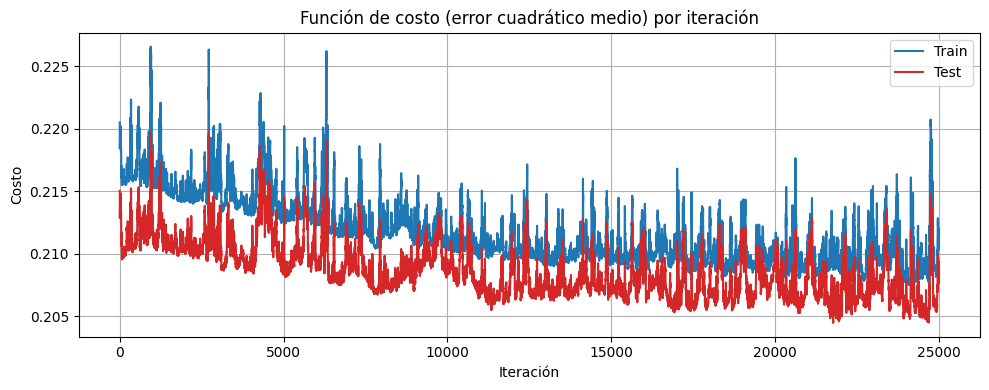

In [75]:
# Graficamos la funcion de costo a lo largo de las iteraciones.
plt.figure(figsize=(10, 4))

# Costo en entrenamiento.
plt.plot(costo_train_l, label='Train', color='tab:blue')

# Costo en prueba.
plt.plot(costo_test_l, label='Test', color='tab:red')

plt.title('Función de costo (error cuadrático medio) por iteración')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [76]:
# Mostramos los resultados finales del entrenamiento.
print("Accuracy train:", accuracy_train_l[-1])
print("Accuracy test:", accuracy_test_l[-1])


Accuracy train: 0.6726190476190453
Accuracy test: 0.6758241758241736


In [73]:
# Calculamos un baseline simple.
# Es el accuracy que tendria un modelo que predice siempre la clase mayoritaria.
baseline = max(np.mean(Y_test == 0), np.mean(Y_test == 1))

# Si la red supera este valor, significa que aprendio algo mas que solo predecir la mayoria.
baseline


np.float64(0.6263736263736264)